# Generation Evaluation Analysis

This notebook analyzes the verdict generation evaluation JSON. It focuses on: 

- Top $n$ most frequent retrieved law articles
- Top $n$ most frequent applied law articles from the model prediction
- Top $n$ most frequent law articles in the ground truth
- Most accurate and least accurate cases by `Phat_tu` RMSE

The article counts are computed at the *Dieu* level by taking the prefix before the first hyphen, so `174-4-a` is counted as article `174`.

In [1]:
from collections import Counter
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 160)

RESULT_PATH = Path("output/generation_eval/system_afterfix_first50.json")
RESULT_PATH_2 = Path("output/generation_eval/combine__first250.json")
RESULT_PATH_3 = Path("output/generation_eval/verdict_generation_eval_reasoning50.json")

TOP_N = 10

print(f"Loading: {RESULT_PATH.resolve()}")

Loading: /home/hieujayce/Downloads/complete_repo/output/generation_eval/system_afterfix_first50.json


In [2]:
with RESULT_PATH.open(encoding="utf-8") as fh:
    result = json.load(fh)

per_doc = result.get("per_doc", [])
summary = result.get("summary", {})

def article_from_signature(signature):
    text = str(signature or "").strip()
    if not text:
        return None
    article = text.split("-", 1)[0].strip()
    return article or None

def normalize_signature_list(value):
    if value is None:
        return []
    if isinstance(value, str):
        return [part.strip() for part in value.split(",") if part.strip()]
    if isinstance(value, list):
        out = []
        for item in value:
            if isinstance(item, dict):
                signature = item.get("signature") or item.get("dieu") or item.get("article")
                if signature:
                    out.append(str(signature).strip())
            else:
                text = str(item).strip()
                if text:
                    out.append(text)
        return out
    return [str(value).strip()] if str(value).strip() else []

def article_set_from_values(values):
    return sorted({article_from_signature(signature) for signature in normalize_signature_list(values) if article_from_signature(signature)})

def collect_articles_from_defendants(doc, side):
    articles = set()
    defendants = doc.get("defendants") or []
    if not isinstance(defendants, list):
        defendants = []
    for item in defendants:
        if not isinstance(item, dict):
            continue
        payload = item.get(side) or {}
        if not isinstance(payload, dict):
            continue
        articles.update(article_set_from_values(payload.get("Applied_Law_Clauses", [])))
    return sorted(articles)

rows = []
for doc in per_doc:
    if doc.get("status") != "processed":
        continue

    similar_case_context = doc.get("similar_case_context") or {}
    retrieved_articles = article_set_from_values(similar_case_context.get("similar_case_law_clause_set", []))
    predicted_articles = collect_articles_from_defendants(doc, "prediction")
    ground_truth_articles = collect_articles_from_defendants(doc, "ground_truth")

    rows.append({
        "doc_id": doc.get("doc_id", ""),
        "source_file": doc.get("source_file", ""),
        "rmse_months": float(doc.get("doc_metrics", {}).get("phat_tu_rmse_months", 0.0)),
        "n_defendants_scored": int(doc.get("doc_metrics", {}).get("n_defendants_scored", 0)),
        "retrieved_articles": retrieved_articles,
        "predicted_articles": predicted_articles,
        "ground_truth_articles": ground_truth_articles,
    })

df = pd.DataFrame(rows)

print(f"Processed documents: {len(df)}")
display(df.head())

print("Summary metrics from JSON:")
display(pd.DataFrame([summary.get("metrics", {})]))

Processed documents: 49


,doc_id,source_file,rmse_months,n_defendants_scored,retrieved_articles,predicted_articles,ground_truth_articles
0,01-02-2024-Hai_Duong-2ta1428714t1cvn,01-02-2024-Hai_Duong-2ta1428714t1cvn.json,6.0,1,"[101, 174, 290, 341, 38, 46, 47, 48, 50, 51, 52, 54, 55, 56, 91]","[174, 51]","[174, 38, 47, 51]"
1,01-02-2024-Nghe_An-2ta1438281t1cvn,01-02-2024-Nghe_An-2ta1438281t1cvn.json,24.0,1,"[15, 17, 348, 349, 38, 46, 47, 51, 52, 54, 56, 57, 65]","[349, 51]","[349, 51, 65]"
2,01-02-2024-Son_La-2ta1431264t1cvn,01-02-2024-Son_La-2ta1431264t1cvn.json,24.0,1,"[249, 250, 251, 37, 38, 47, 51, 52, 58]","[250, 51]","[251, 47, 51]"
3,01-03-2024-Ben_Tre-2ta1485023t1cvn,01-03-2024-Ben_Tre-2ta1485023t1cvn.json,72.0,1,"[101, 142, 145, 146, 38, 46, 47, 48, 50, 51, 52, 54, 55, 58, 91, 98]","[142, 51]","[142, 38, 51, 54]"
4,01-03-2024-Gia_Lai-2ta1457995t1cvn,01-03-2024-Gia_Lai-2ta1457995t1cvn.json,324.0,1,"[12, 123, 134, 15, 17, 318, 38, 47, 48, 50, 51, 52, 54, 55, 56, 57, 58, 65]","[134, 51, 52, 56]","[134, 38, 51, 52, 55, 56]"


Summary metrics from JSON:


,law_clause_set_precision_macro,law_clause_set_recall_macro,law_clause_set_f1_macro,phat_tu_rmse_months_macro
0,0.785941,0.520708,0.596716,49.840159


Top retrieved law articles


,article,case_count,share_of_cases
0,51,49,1.0000
1,47,49,1.0000
2,38,49,1.0000
3,52,49,1.0000
4,58,36,0.7347
5,54,33,0.6735
6,46,30,0.6122
7,17,27,0.5510
8,55,26,0.5306
9,48,24,0.4898


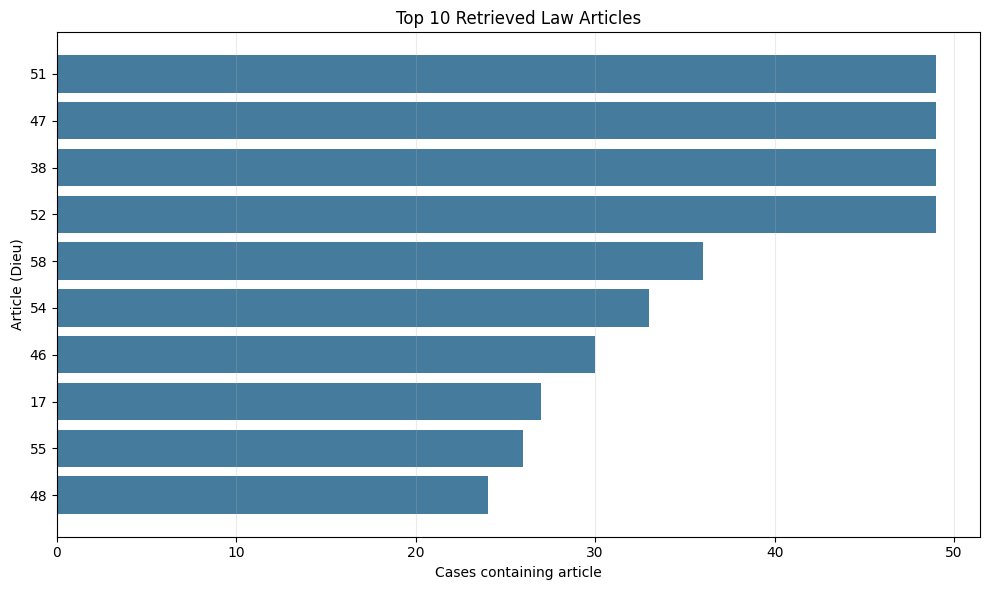

Top applied law articles from model predictions


,article,case_count,share_of_cases
0,51,49,1.0000
1,17,11,0.2245
2,52,8,0.1633
3,174,7,0.1429
4,251,7,0.1429
5,123,6,0.1224
6,134,4,0.0816
7,173,3,0.0612
8,191,3,0.0612
9,249,3,0.0612


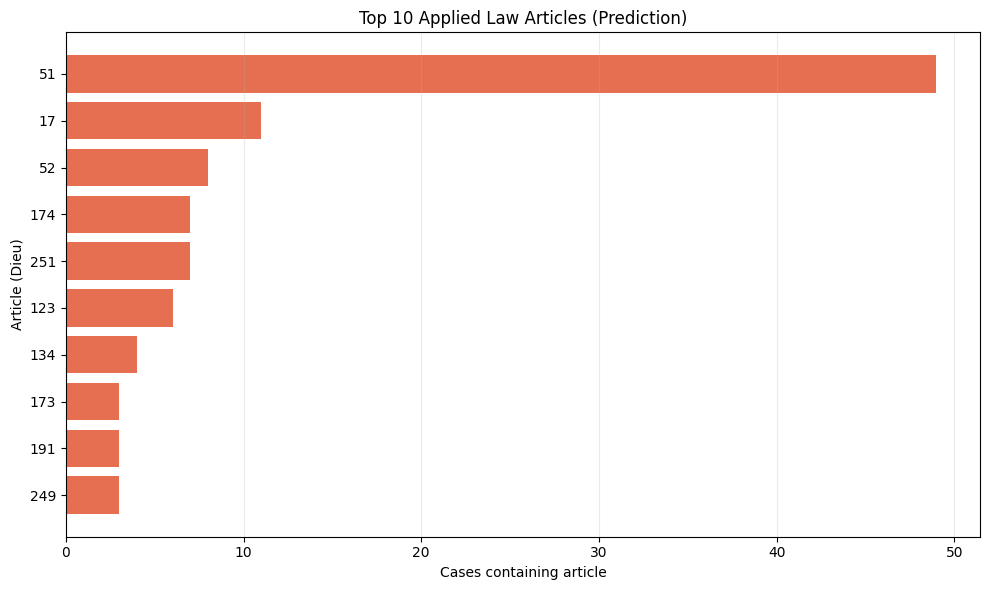

Top ground-truth law articles


,article,case_count,share_of_cases
0,51,47,0.9592
1,38,20,0.4082
2,47,19,0.3878
3,52,13,0.2653
4,123,10,0.2041
5,251,8,0.1633
6,54,8,0.1633
7,55,8,0.1633
8,174,6,0.1224
9,65,5,0.1020


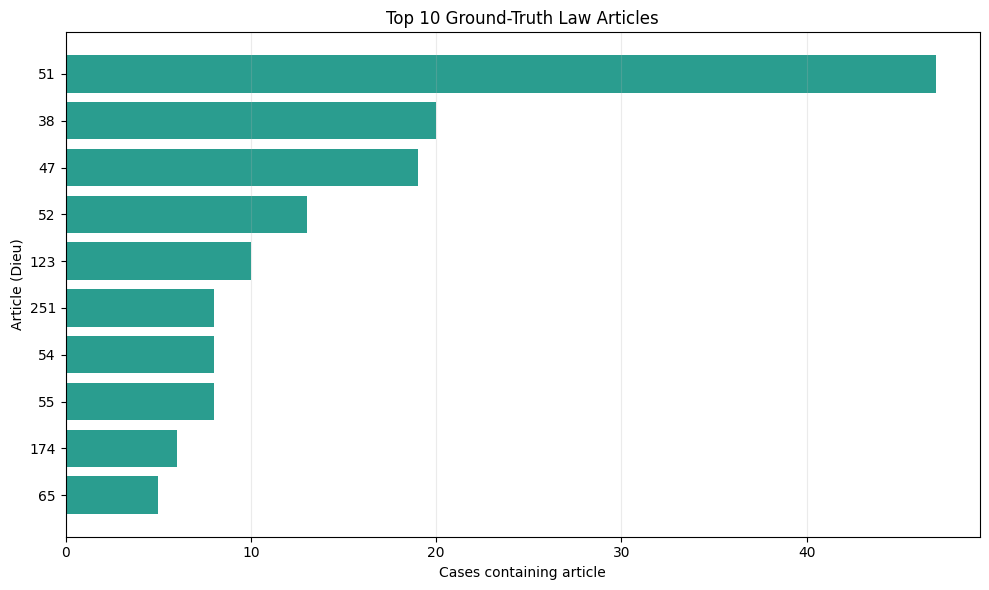

In [3]:
def count_articles(series):
    counter = Counter()
    for articles in series:
        counter.update(set(articles))
    return counter

def top_articles_table(counter, total_docs, n=10):
    rows = []
    for article, count in counter.most_common(n):
        rows.append({
            "article": article,
            "case_count": count,
            "share_of_cases": round(count / total_docs, 4) if total_docs else 0.0,
        })
    return pd.DataFrame(rows)

def plot_top_articles(counter, title, n=10, color="#2a9d8f"):
    top_items = counter.most_common(n)
    if not top_items:
        print(f"No data available for {title}")
        return

    articles = [item[0] for item in top_items][::-1]
    counts = [item[1] for item in top_items][::-1]

    fig, ax = plt.subplots(figsize=(10, max(4, 0.5 * len(top_items) + 1)))
    ax.barh(articles, counts, color=color)
    ax.set_title(title)
    ax.set_xlabel("Cases containing article")
    ax.set_ylabel("Article (Dieu)")
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()

total_docs = len(df)
retrieved_counter = count_articles(df["retrieved_articles"])
predicted_counter = count_articles(df["predicted_articles"])
ground_truth_counter = count_articles(df["ground_truth_articles"])

print("Top retrieved law articles")
display(top_articles_table(retrieved_counter, total_docs, TOP_N))
plot_top_articles(retrieved_counter, f"Top {TOP_N} Retrieved Law Articles", TOP_N, color="#457b9d")

print("Top applied law articles from model predictions")
display(top_articles_table(predicted_counter, total_docs, TOP_N))
plot_top_articles(predicted_counter, f"Top {TOP_N} Applied Law Articles (Prediction)", TOP_N, color="#e76f51")

print("Top ground-truth law articles")
display(top_articles_table(ground_truth_counter, total_docs, TOP_N))
plot_top_articles(ground_truth_counter, f"Top {TOP_N} Ground-Truth Law Articles", TOP_N, color="#2a9d8f")

Most accurate cases by Phat_tu RMSE (lower is better): top 10


,doc_id,source_file,rmse_months,n_defendants_scored
0,03-06-2024-Khanh_Hoa-2ta1516703t1cvn,03-06-2024-Khanh_Hoa-2ta1516703t1cvn.json,0.0,1
1,04-01-2024-Khanh_Hoa-2ta1427000t1cvn,04-01-2024-Khanh_Hoa-2ta1427000t1cvn.json,0.0,1
2,02-12-2024-Ho_Chi_Minh-2ta1793380t1cvn,02-12-2024-Ho_Chi_Minh-2ta1793380t1cvn.json,0.0,1
3,05-01-2024-Lai_Chau-2ta1406042t1cvn,05-01-2024-Lai_Chau-2ta1406042t1cvn.json,0.0,1
4,07-11-2024-Binh_Phuoc-2ta1747164t1cvn,07-11-2024-Binh_Phuoc-2ta1747164t1cvn.json,0.0,1
5,09-01-2024-Hung_Yen-2ta1637367t1cvn,09-01-2024-Hung_Yen-2ta1637367t1cvn.json,0.0,1
6,07-02-2024-Hung_Yen-2ta1637341t1cvn,07-02-2024-Hung_Yen-2ta1637341t1cvn.json,0.0,1
7,08-04-2024-Cao_Bang-2ta1480998t1cvn,08-04-2024-Cao_Bang-2ta1480998t1cvn.json,1.0,1
8,07-03-2024-Khanh_Hoa-2ta1515205t1cvn,07-03-2024-Khanh_Hoa-2ta1515205t1cvn.json,2.0,1
9,08-11-2024-Phu_Yen-2ta1696902t1cvn,08-11-2024-Phu_Yen-2ta1696902t1cvn.json,3.0,1


Least accurate cases by Phat_tu RMSE (higher is worse): top 10


,doc_id,source_file,rmse_months,n_defendants_scored
0,01-03-2024-Gia_Lai-2ta1457995t1cvn,01-03-2024-Gia_Lai-2ta1457995t1cvn.json,324.000000,1
1,03-05-2024-Lai_Chau-2ta1503009t1cvn,03-05-2024-Lai_Chau-2ta1503009t1cvn.json,204.000000,1
2,04-12-2024-Ha_Giang-2ta1704785t1cvn,04-12-2024-Ha_Giang-2ta1704785t1cvn.json,180.000000,1
3,08-11-2024-Ha_Noi-2ta1893925t1cvn,08-11-2024-Ha_Noi-2ta1893925t1cvn.json,144.000000,1
4,05-12-2024-Ho_Chi_Minh-2ta1972811t1cvn,05-12-2024-Ho_Chi_Minh-2ta1972811t1cvn.json,144.000000,1
5,06-08-2024-Quang_Ninh-2ta1582983t1cvn,06-08-2024-Quang_Ninh-2ta1582983t1cvn.json,104.462912,2
6,02-07-2024-Ca_Mau-2ta1556010t1cvn,02-07-2024-Ca_Mau-2ta1556010t1cvn.json,96.000000,1
7,04-01-2024-Khanh_Hoa-2ta1438283t1cvn,04-01-2024-Khanh_Hoa-2ta1438283t1cvn.json,96.000000,1
8,06-05-2024-Nghe_An-2ta1800216t1cvn,06-05-2024-Nghe_An-2ta1800216t1cvn.json,90.199778,2
9,09-01-2024-Ho_Chi_Minh-2ta1615819t1cvn,09-01-2024-Ho_Chi_Minh-2ta1615819t1cvn.json,84.000000,1


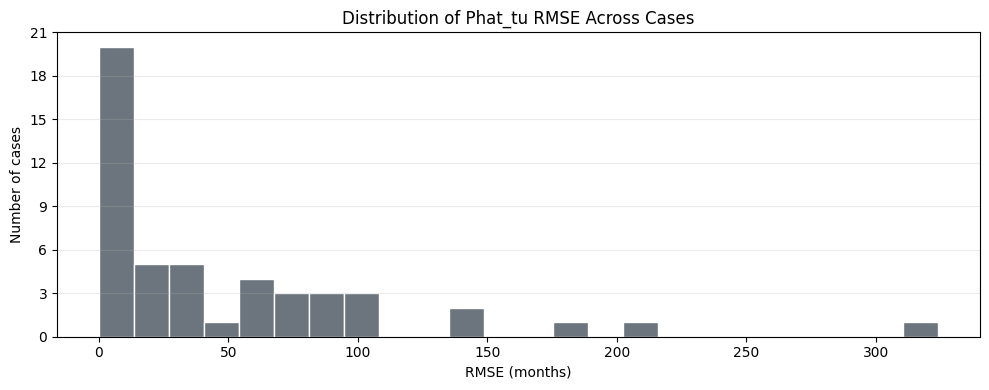

In [4]:
rmse_df = df[["doc_id", "source_file", "rmse_months", "n_defendants_scored"]].copy()
rmse_df = rmse_df.sort_values("rmse_months", ascending=True).reset_index(drop=True)

best_cases = rmse_df.head(TOP_N)
worst_cases = rmse_df.sort_values("rmse_months", ascending=False).head(TOP_N).reset_index(drop=True)

print(f"Most accurate cases by Phat_tu RMSE (lower is better): top {TOP_N}")
display(best_cases)

print(f"Least accurate cases by Phat_tu RMSE (higher is worse): top {TOP_N}")
display(worst_cases)

from matplotlib.ticker import MaxNLocator

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df["rmse_months"], bins=min(40, max(10, len(df) // 2)), color="#6c757d", edgecolor="white")
ax.set_title("Distribution of Phat_tu RMSE Across Cases")
ax.set_xlabel("RMSE (months)")
ax.set_ylabel("Number of cases")
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## Notes

- The article frequency summaries are document-frequency counts: each article is counted once per case if it appears in that case.
- Retrieved articles come from `similar_case_context.similar_case_law_clause_set`.
- Applied articles come from the model prediction `Applied_Law_Clauses`.
- Ground-truth articles come from `ground_truth.Applied_Law_Clauses`.
- The RMSE ranking uses the case-level `doc_metrics.phat_tu_rmse_months` value.

Loading RESULT_PATH_2: /home/hieujayce/Downloads/complete_repo/output/generation_eval/combine__first250.json
Processed documents: 249
Least accurate cases by Phat_tu RMSE (higher is worse): top 30


,doc_id,source_file,rmse_months,n_defendants_scored
0,26-08-2024-Binh_Duong-2ta1611477t1cvn,26-08-2024-Binh_Duong-2ta1611477t1cvn.json,360.000000,1
1,15-01-2024-Lao_Cai-2ta1414126t1cvn,15-01-2024-Lao_Cai-2ta1414126t1cvn.json,360.000000,1
2,22-01-2024-Bac_Ninh-2ta1452929t1cvn,22-01-2024-Bac_Ninh-2ta1452929t1cvn.json,360.000000,1
3,12-03-2024-Binh_Thuan-2ta1456528t1cvn,12-03-2024-Binh_Thuan-2ta1456528t1cvn.json,255.828067,2
4,28-06-2024-Dien_Bien-2ta1555787t1cvn,28-06-2024-Dien_Bien-2ta1555787t1cvn.json,241.793300,4
5,26-08-2024-Dien_Bien-2ta1616335t1cvn,26-08-2024-Dien_Bien-2ta1616335t1cvn.json,240.000000,1
6,22-03-2024-Dien_Bien-2ta1467089t1cvn,22-03-2024-Dien_Bien-2ta1467089t1cvn.json,240.000000,1
7,16-01-2024-Ha_Noi-2ta1481575t1cvn,16-01-2024-Ha_Noi-2ta1481575t1cvn.json,240.000000,1
8,22-07-2024-Lao_Cai-2ta1576399t1cvn,22-07-2024-Lao_Cai-2ta1576399t1cvn.json,216.000000,1
9,24-12-2024-Thanh_Hoa-2ta1725500t1cvn,24-12-2024-Thanh_Hoa-2ta1725500t1cvn.json,216.000000,1


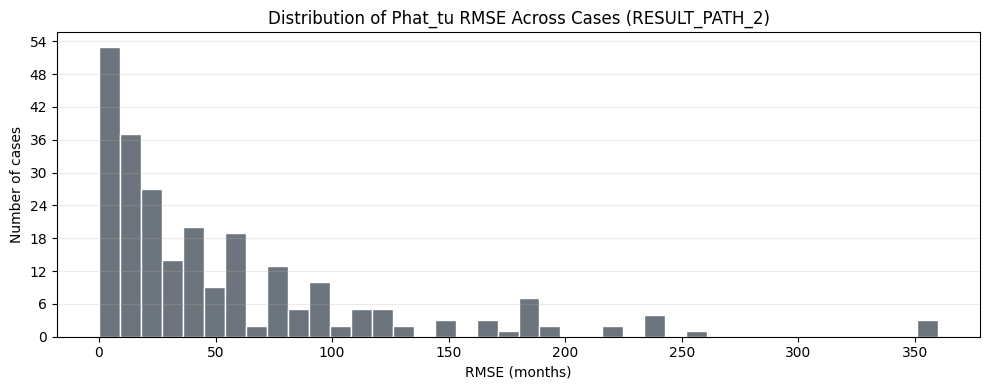

Loading RESULT_PATH_3: /home/hieujayce/Downloads/complete_repo/output/generation_eval/verdict_generation_eval_reasoning50.json
Processed documents: 50
Least accurate cases by Phat_tu RMSE (higher is worse): top 30


,doc_id,source_file,rmse_months,n_defendants_scored
0,01-03-2024-Gia_Lai-2ta1457995t1cvn,01-03-2024-Gia_Lai-2ta1457995t1cvn.json,324.000000,1
1,06-09-2024-Dak_Nong-2ta1671757t1cvn,06-09-2024-Dak_Nong-2ta1671757t1cvn.json,216.000000,1
2,03-05-2024-Lai_Chau-2ta1503009t1cvn,03-05-2024-Lai_Chau-2ta1503009t1cvn.json,156.000000,1
3,01-04-2024-Dong_Thap-2ta1563371t1cvn,01-04-2024-Dong_Thap-2ta1563371t1cvn.json,142.828569,3
4,04-01-2024-Khanh_Hoa-2ta1438283t1cvn,04-01-2024-Khanh_Hoa-2ta1438283t1cvn.json,120.000000,1
5,05-12-2024-Ho_Chi_Minh-2ta1972811t1cvn,05-12-2024-Ho_Chi_Minh-2ta1972811t1cvn.json,108.000000,1
6,05-03-2024-Nghe_An-2ta1542942t1cvn,05-03-2024-Nghe_An-2ta1542942t1cvn.json,96.000000,1
7,08-11-2024-Ha_Noi-2ta1893925t1cvn,08-11-2024-Ha_Noi-2ta1893925t1cvn.json,96.000000,1
8,04-12-2024-Ha_Giang-2ta1704785t1cvn,04-12-2024-Ha_Giang-2ta1704785t1cvn.json,90.000000,1
9,06-08-2024-Quang_Ninh-2ta1582983t1cvn,06-08-2024-Quang_Ninh-2ta1582983t1cvn.json,86.142324,2


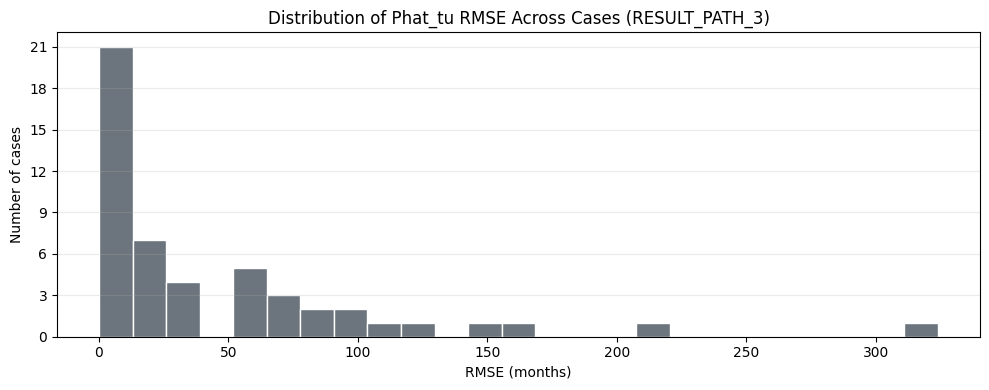

In [6]:
TOP_N = 30
def analyze_result_path(result_path, label):
    with result_path.open(encoding="utf-8") as fh:
        result = json.load(fh)

    per_doc = result.get("per_doc", [])
    rows = []
    for doc in per_doc:
        if doc.get("status") != "processed":
            continue
        rows.append({
            "doc_id": doc.get("doc_id", ""),
            "source_file": doc.get("source_file", ""),
            "rmse_months": float(doc.get("doc_metrics", {}).get("phat_tu_rmse_months", 0.0)),
            "n_defendants_scored": int(doc.get("doc_metrics", {}).get("n_defendants_scored", 0)),
        })

    df_local = pd.DataFrame(rows)
    rmse_df = df_local[["doc_id", "source_file", "rmse_months", "n_defendants_scored"]].copy()
    rmse_df = rmse_df.sort_values("rmse_months", ascending=True).reset_index(drop=True)
    worst_cases = rmse_df.sort_values("rmse_months", ascending=False).head(TOP_N).reset_index(drop=True)

    print(f"Loading {label}: {result_path.resolve()}")
    print(f"Processed documents: {len(df_local)}")
    print(f"Least accurate cases by Phat_tu RMSE (higher is worse): top {TOP_N}")
    display(worst_cases)

    from matplotlib.ticker import MaxNLocator

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(rmse_df["rmse_months"], bins=min(40, max(10, len(rmse_df) // 2)), color="#6c757d", edgecolor="white")
    ax.set_title(f"Distribution of Phat_tu RMSE Across Cases ({label})")
    ax.set_xlabel("RMSE (months)")
    ax.set_ylabel("Number of cases")
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()
    plt.close(fig)


analyze_result_path(RESULT_PATH_2, "RESULT_PATH_2")
analyze_result_path(RESULT_PATH_3, "RESULT_PATH_3")